# Super Store - US sales analysis (Jan-Jun 2015)

**Question:** where does Super Store make and lose money, and what should the regional managers do about it?

The data is 1,952 order lines from the `Orders` sheet, joined to `Returns` (by Order ID) and `Users` (by Region, for the manager name).
All cleaning and feature engineering happens in [`src/transform.py`](../src/transform.py). This notebook runs it, then goes through the analysis.

**Contents**
1. Load & validate
2. Headline KPIs
3. Trend over time
4. Product mix
5. Regions, managers & states
6. Discounts & order size (the main profit driver)
7. Shipping & order priority
8. Customers
9. Returns
10. Data-quality caveats
11. Findings & recommendations

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np
import pandas as pd
import seaborn as sns

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))
import transform

FIG = ROOT / "figures"
FIG.mkdir(exist_ok=True)
pd.set_option("display.float_format", "{:,.2f}".format)

# Palette: one blue for magnitude and gain, one red for loss (a diverging pair), gray for context.
BLUE, RED, GRAY, INK, MUTED = "#2a78d6", "#e34948", "#b9b8b2", "#0b0b0b", "#898781"
CAT = {"Office Supplies": "#2a78d6", "Technology": "#eb6834", "Furniture": "#1baf7a"}
plt.rcParams.update({
    "figure.facecolor": "#fcfcfb", "axes.facecolor": "#fcfcfb", "savefig.facecolor": "#fcfcfb",
    "axes.edgecolor": MUTED, "axes.labelcolor": "#52514e", "xtick.color": "#52514e",
    "ytick.color": "#52514e", "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": "#e6e5e0", "grid.linewidth": 0.8, "axes.axisbelow": True,
    "font.size": 10, "axes.titlesize": 12, "axes.titleweight": "bold", "axes.titlelocation": "left",
    "figure.dpi": 110,
})
usd = mtick.FuncFormatter(lambda v, _: ("-" if v < 0 else "") + (f"${abs(v)/1e3:,.0f}k" if abs(v) >= 1e3 else f"${abs(v):,.0f}"))
pct = mtick.PercentFormatter(1.0, decimals=0)

def save(fig, name):
    fig.savefig(FIG / f"{name}.png", bbox_inches="tight", dpi=150)

def summarize(df, by):
    g = df.groupby(by, observed=True).agg(sales=("Sales", "sum"), profit=("Profit", "sum"),
                                          lines=("Sales", "size"), loss_share=("Is Loss", "mean"),
                                          avg_discount=("Discount", "mean"))
    g["margin"] = g["profit"] / g["sales"]
    return g

## 1. Load & validate
The pipeline prints what it found and what it fixed. The same log goes to `reports/data_quality.md`.

In [2]:
df = transform.run()
df.shape

Loaded Orders (1952, 25), Returns (1634, 2), Users (4, 2).
Trimmed whitespace in 12 text columns; `Order Priority` went from 6 to 5 distinct values.
Re-padded 152 postal codes to 5 digits (e.g. 7203 -> 07203).
`Row ID` is not unique ([22015] appears twice on different lines); added a surrogate `Line Key` and kept both rows.
Imputed 16 missing `Product Base Margin` values with the sub-category median (flagged in `Base Margin Imputed`).
104 Order IDs are shared by more than one customer (257 lines); some even span regions. Kept as-is and flagged (`Order ID Shared`) - order-level counts should be read with care.
Joined Returns on `Order ID`: only 11 of 1634 returned order IDs exist in Orders (15 lines). Returns appears to come from a wider (global) order book, so return-rate figures are indicative only.
Joined Users on `Region` to attach the responsible regional `Manager`.
Engineered: ship days, calendar parts, gross sales, discount amount, profit margin, loss flag, margin gap vs. base ma

(1952, 46)

In [3]:
# Sanity checks on the transformed table
assert df["Line Key"].is_unique
assert (df["Ship Days"] >= 0).all(), "ship date before order date"
assert df["Manager"].notna().all(), "region without a manager"
assert df["State Code"].notna().all()
assert df["Order Priority"].nunique() == 5
df[["Order Date", "Customer Name", "Product Category", "Region", "Manager",
    "Sales", "Profit", "Profit Margin", "Ship Days", "Returned"]].head()

,Order Date,Customer Name,Product Category,Region,Manager,Sales,Profit,Profit Margin,Ship Days,Returned
0,2015-01-07,Bonnie Potter,Office Supplies,West,William,13.01,4.56,0.35,1,False
1,2015-06-13,Ronnie Proctor,Furniture,West,William,"6,362.85","4,390.37",0.69,2,False
2,2015-02-15,Marcus Dunlap,Furniture,East,Erin,211.15,-53.81,-0.25,2,False
3,2015-05-12,Gwendolyn F Tyson,Furniture,Central,Chris,"1,164.45",803.47,0.69,2,False
4,2015-05-12,Gwendolyn F Tyson,Office Supplies,Central,Chris,22.23,-24.03,-1.08,1,False


## 2. Headline KPIs

In [4]:
kpi = pd.Series({
    "Sales": df["Sales"].sum(),
    "Profit": df["Profit"].sum(),
    "Profit margin": df["Profit"].sum() / df["Sales"].sum(),
    "Order lines": len(df),
    "Orders": df["Order ID"].nunique(),
    "Customers": df["Customer ID"].nunique(),
    "Avg discount": df["Discount"].mean(),
    "Loss-making lines": df["Is Loss"].mean(),
    "Total lost on loss lines": df.loc[df["Is Loss"], "Profit"].sum(),
    "Avg days to ship": df["Ship Days"].mean(),
})
kpi.to_frame("value").style.format({"value": "{:,.2f}"})

,value
Sales,"1,924,337.88"
Profit,"224,077.61"
Profit margin,0.12
Order lines,"1,952.00"
Orders,"1,365.00"
Customers,"1,130.00"
Avg discount,0.05
Loss-making lines,0.49
Total lost on loss lines,"-291,448.04"
Avg days to ship,1.94


Sales of **$1.92M** earned **$224k** profit, an **11.6% margin**. Almost **half of all order lines (49%) lose money**, and together they lose **$291k**.
The profitable lines therefore earned about $515k to cover those losses. The rest of the notebook looks at where the losses come from.

## 3. Trend over time
Sales and margin use different units, so they get separate panels that share the x-axis. There is no dual y-axis.

,sales,profit,lines,loss_share,avg_discount,margin
Order Month,,,,,,
2015-01-01,"274,766.92","1,043.68",370,0.56,0.05,0.00
2015-02-01,"326,101.47","35,944.66",314,0.52,0.05,0.11
2015-03-01,"271,696.67",103.16,328,0.54,0.05,0.00
2015-04-01,"389,831.95","53,146.41",321,0.44,0.05,0.14
2015-05-01,"306,572.07","67,002.73",313,0.35,0.05,0.22
2015-06-01,"355,368.80","66,836.97",306,0.52,0.05,0.19


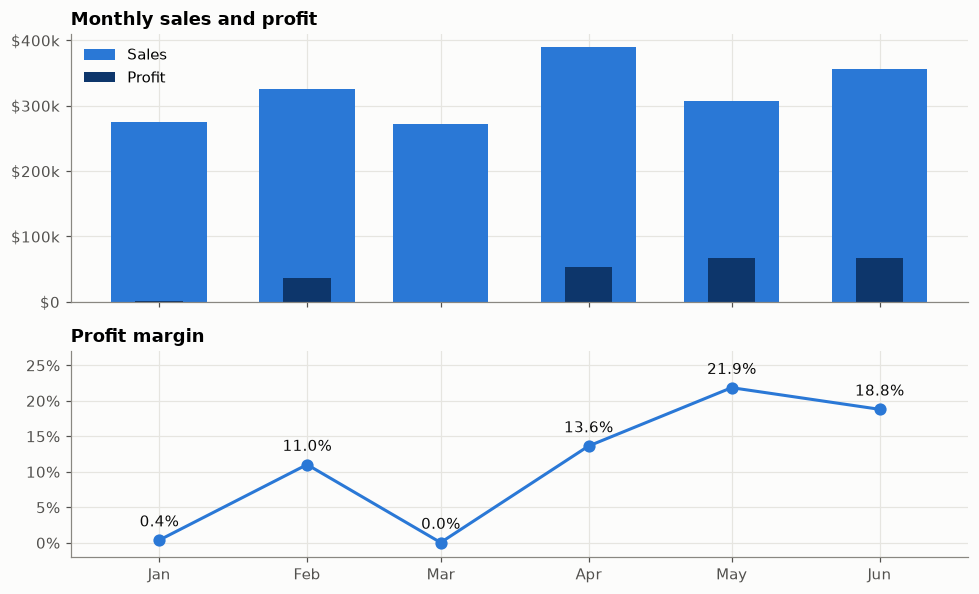

In [5]:
m = summarize(df, "Order Month")
fig, (a1, a2) = plt.subplots(2, 1, figsize=(9, 5.5), sharex=True, height_ratios=[1.3, 1])
a1.bar(m.index, m["sales"], width=20, color=BLUE, label="Sales")
a1.bar(m.index, m["profit"], width=10, color="#0d366b", label="Profit")
a1.yaxis.set_major_formatter(usd); a1.set_title("Monthly sales and profit"); a1.legend(frameon=False, loc="upper left")
a2.plot(m.index, m["margin"], color=BLUE, lw=2, marker="o", ms=7)
for x, y in m["margin"].items():
    a2.annotate(f"{y:.1%}", (x, y), textcoords="offset points", xytext=(0, 9), ha="center", color=INK)
a2.yaxis.set_major_formatter(pct); a2.set_title("Profit margin"); a2.set_ylim(-0.02, 0.27)
a2.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter("%b"))
fig.tight_layout(); save(fig, "01_monthly_trend")
m

**Margin rose from about 0% in Jan and Mar to about 20% in May-Jun.** Sales stayed within a narrow band ($270k-$390k), so the gain came from fewer losses, not more volume.
The loss-line share fell from 56% in January to 35% in May. January and March were each close to breakeven because of a few very large loss lines, covered in section 5.

## 4. Product mix

,Product Category,sales,profit,margin,lines
Product Sub-Category,,,,,
Tables,Furniture,"193,764.58","-7,240.07",-0.04,80
Rubber Bands,Office Supplies,"1,789.43","-1,544.83",-0.86,34
"Scissors, Rulers and Trimmers",Office Supplies,"6,752.18","-1,291.10",-0.19,36
Envelopes,Office Supplies,"10,479.77","-1,194.41",-0.11,55
Bookcases,Furniture,"107,796.09",-930.44,-0.01,43
Pens & Art Supplies,Office Supplies,"26,071.61",-257.63,-0.01,161
Computer Peripherals,Technology,"96,261.30","1,698.04",0.02,174
Labels,Office Supplies,"4,914.82","7,028.16",1.43,71
Storage & Organization,Office Supplies,"177,417.60","7,124.29",0.04,130


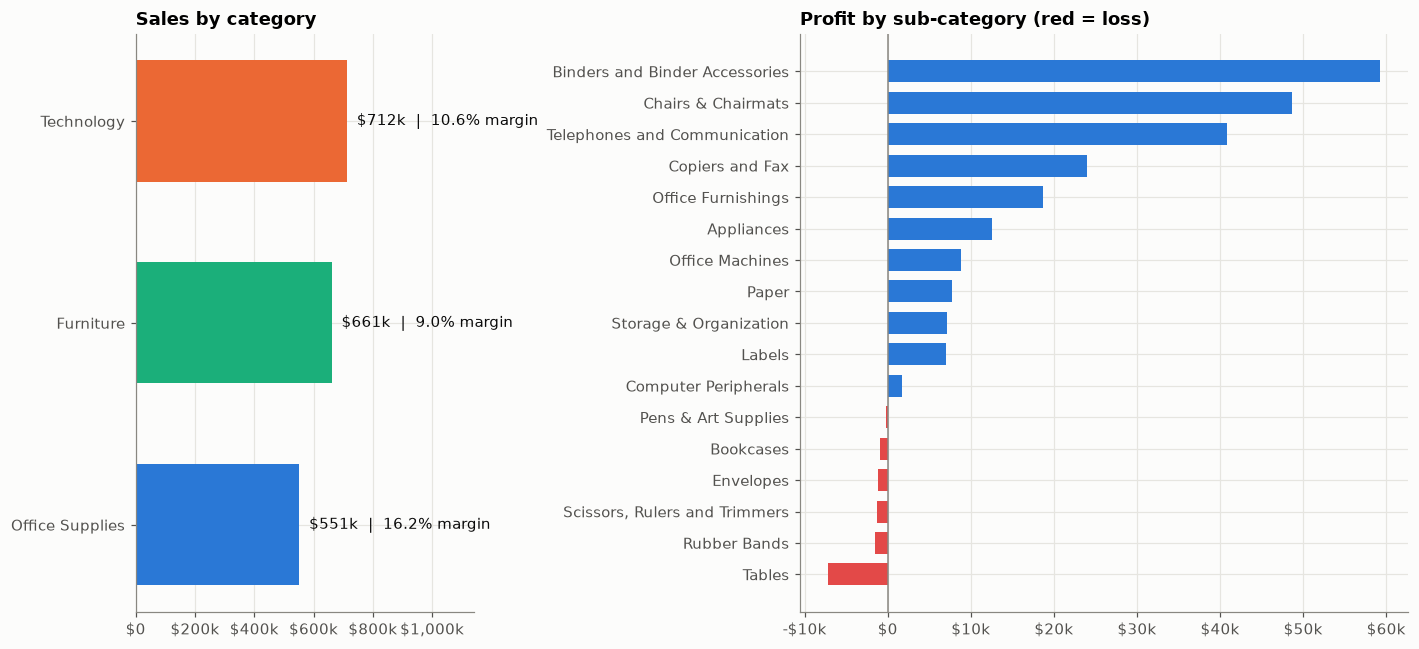

In [6]:
cat = summarize(df, "Product Category").sort_values("sales")
sub = summarize(df, ["Product Category", "Product Sub-Category"]).reset_index().sort_values("profit")

fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 6), width_ratios=[1, 1.8])
a1.barh(cat.index, cat["sales"], color=[CAT[c] for c in cat.index], height=0.6)
for i, (s, mg) in enumerate(zip(cat["sales"], cat["margin"])):
    a1.text(s, i, f"  ${s/1e3:,.0f}k  |  {mg:.1%} margin", va="center", color=INK)
a1.xaxis.set_major_formatter(usd); a1.set_title("Sales by category"); a1.set_xlim(0, cat["sales"].max() * 1.6)

a2.barh(sub["Product Sub-Category"], sub["profit"], color=np.where(sub["profit"] < 0, RED, BLUE), height=0.7)
a2.axvline(0, color=MUTED, lw=1)
a2.xaxis.set_major_formatter(usd); a2.set_title("Profit by sub-category (red = loss)")
fig.tight_layout(); save(fig, "02_product_mix")
sub.set_index("Product Sub-Category")[["Product Category", "sales", "profit", "margin", "lines"]]

* **Office Supplies** has the lowest sales of the three categories but the **highest profit and margin (16%)**. Binders alone earn $59k.
* **Technology** has the highest sales ($712k) but only a 10.6% margin. **Furniture** is the weakest at 9%.
* Six sub-categories lose money. **Tables** is the biggest problem: -$7.2k on $194k of sales. **Bookcases** only breaks even.
* Small items like Rubber Bands, Envelopes and Scissors lose money on almost every line. Shipping and handling seem to cost more than the item is worth (see section 6).

## 5. Regions, managers & states

,sales,profit,margin,loss_share,lines
label,,,,,
South (Sam),"357,105.12","-14,424.05",-0.04,0.53,442
West (William),"526,776.57","75,844.79",0.14,0.49,470
Central (Chris),"448,284.70","77,365.47",0.17,0.46,566
East (Erin),"592,171.49","85,291.40",0.14,0.49,474


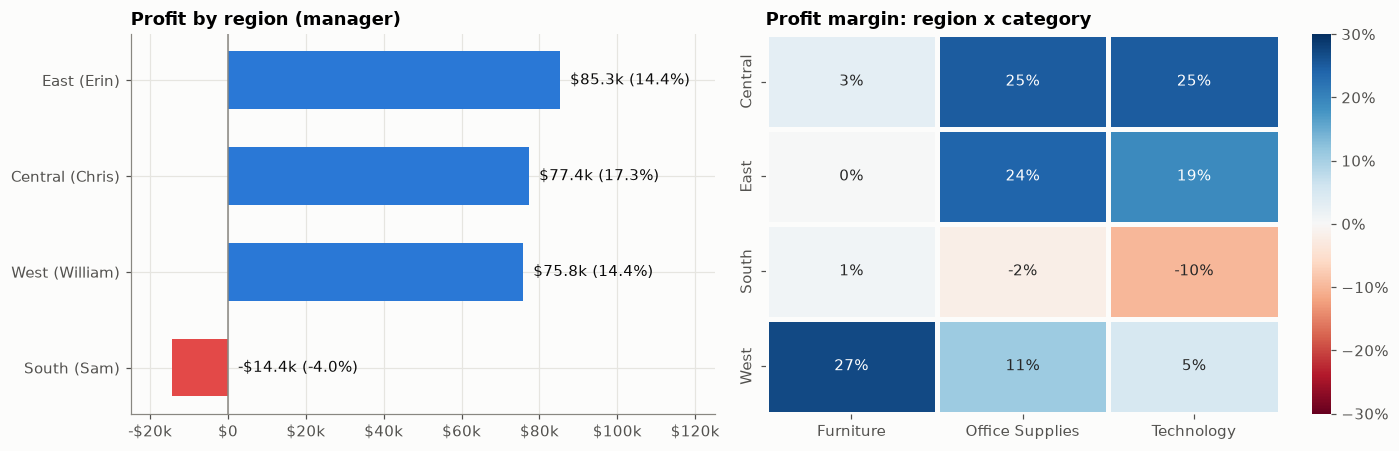

In [7]:
reg = summarize(df, ["Region", "Manager"]).reset_index().sort_values("profit")
reg["label"] = reg["Region"] + " (" + reg["Manager"] + ")"
rc = df.pivot_table(index="Region", columns="Product Category", values=["Profit", "Sales"], aggfunc="sum")
rc_margin = rc["Profit"] / rc["Sales"]

fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 4.2), width_ratios=[1, 1.1])
a1.barh(reg["label"], reg["profit"], color=np.where(reg["profit"] < 0, RED, BLUE), height=0.6)
for i, (p, mg) in enumerate(zip(reg["profit"], reg["margin"])):
    a1.text(max(p, 0), i, f"  {'-' if p < 0 else ''}${abs(p)/1e3:,.1f}k ({mg:.1%})", va="center", ha="left", color=INK)
a1.axvline(0, color=MUTED, lw=1); a1.xaxis.set_major_formatter(usd)
a1.set_xlim(-25000, 125000); a1.set_title("Profit by region (manager)")
sns.heatmap(rc_margin.round(2) + 0.0, annot=True, fmt=".0%", cmap="RdBu", center=0, vmin=-0.3, vmax=0.3,
            linewidths=2, linecolor="#fcfcfb", cbar_kws={"format": pct}, ax=a2)
a2.set_title("Profit margin: region x category"); a2.set_xlabel(""); a2.set_ylabel("")
fig.tight_layout(); save(fig, "03_regions")
reg.set_index("label")[["sales", "profit", "margin", "loss_share", "lines"]]

* **South (Sam) is the only loss-making region: -$14.4k on $357k of sales.** Technology in the South loses $13.4k by itself (-10% margin).
* **East (Erin)** has the most sales and profit, but its Furniture breaks even.
* **West (William)** Furniture has a 27% margin while West Technology has only 5%. The same category performs very differently by region, so the cause is local pricing or discounting, not the product.
* **Central (Chris)** has the best margin (17%) and the most order lines.

Top 5 loss lines total $-64,810


,Order Date,State,Region,Product Name,Sales,Profit
975,2015-03-28,North Carolina,South,5165,"1,486.34","-16,476.84"
1605,2015-03-10,Washington,West,Polycom ViewStation™ ISDN Videoconferencing Unit,"6,296.00","-14,140.70"
1006,2015-01-06,Illinois,Central,"Riverside Palais Royal Lawyers Bookcase, Royal...","6,968.90","-13,706.46"
1111,2015-04-17,Montana,West,Polycom ViewStation™ ISDN Videoconferencing Unit,"6,569.07","-13,562.64"
27,2015-01-28,Washington,West,Okidata Pacemark 4410N Wide Format Dot Matrix ...,"3,267.55","-6,923.60"


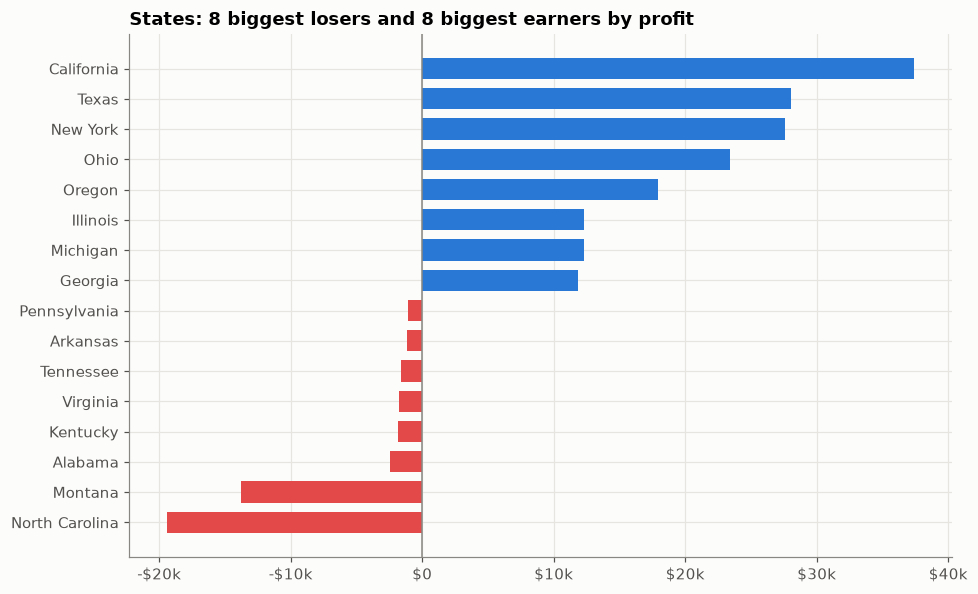

In [8]:
st = summarize(df, ["State", "State Code"]).reset_index().sort_values("profit")
show = pd.concat([st.head(8), st.tail(8)])
fig, ax = plt.subplots(figsize=(9, 5.5))
ax.barh(show["State"], show["profit"], color=np.where(show["profit"] < 0, RED, BLUE), height=0.7)
ax.axvline(0, color=MUTED, lw=1); ax.xaxis.set_major_formatter(usd)
ax.set_title("States: 8 biggest losers and 8 biggest earners by profit")
fig.tight_layout(); save(fig, "04_states")

worst = df.nsmallest(5, "Profit")[["Order Date", "State", "Region", "Product Name", "Sales", "Profit"]]
print(f"Top 5 loss lines total ${worst['Profit'].sum():,.0f}")
worst

In [9]:
# Interactive choropleth (opens in any browser: figures/state_profit_map.html)
try:
    import plotly.express as px
    fig = px.choropleth(st, locations="State Code", locationmode="USA-states", scope="usa",
                        color="profit", color_continuous_scale="RdBu", color_continuous_midpoint=0,
                        hover_name="State", hover_data={"sales": ":$,.0f", "profit": ":$,.0f",
                                                        "margin": ":.1%", "State Code": False},
                        title="Profit by state, H1 2015")
    fig.write_html(FIG / "state_profit_map.html", include_plotlyjs="cdn")
    print("wrote figures/state_profit_map.html")
except ImportError:
    print("plotly not installed - skipping the interactive map")

wrote figures/state_profit_map.html


The state results depend on a handful of very large lines. **North Carolina (-$19k) and Montana (-$14k)** each lose most of that on one line (a "5165" item and a Polycom videoconferencing unit).
Montana has only 7 lines in total. Without those outliers the South would be about breakeven, not a large loss. A manager should review these as individual deals, not as a regional pattern.

## 6. Discounts & order size - the main profit driver

,sales,profit,lines,loss_share,avg_discount,margin,shipping_to_sales
Order Size Band,,,,,,,
<100,"32,938.75","-25,086.79",715,0.62,0.05,-0.76,0.10
100-500,"146,299.40","-16,875.18",595,0.49,0.05,-0.12,0.04
500-2k,"411,168.51","41,137.86",398,0.38,0.05,0.10,0.02
2k-10k,"985,527.92","158,174.37",225,0.32,0.05,0.16,0.01
10k+,"348,403.30","66,727.35",19,0.05,0.04,0.19,0.00


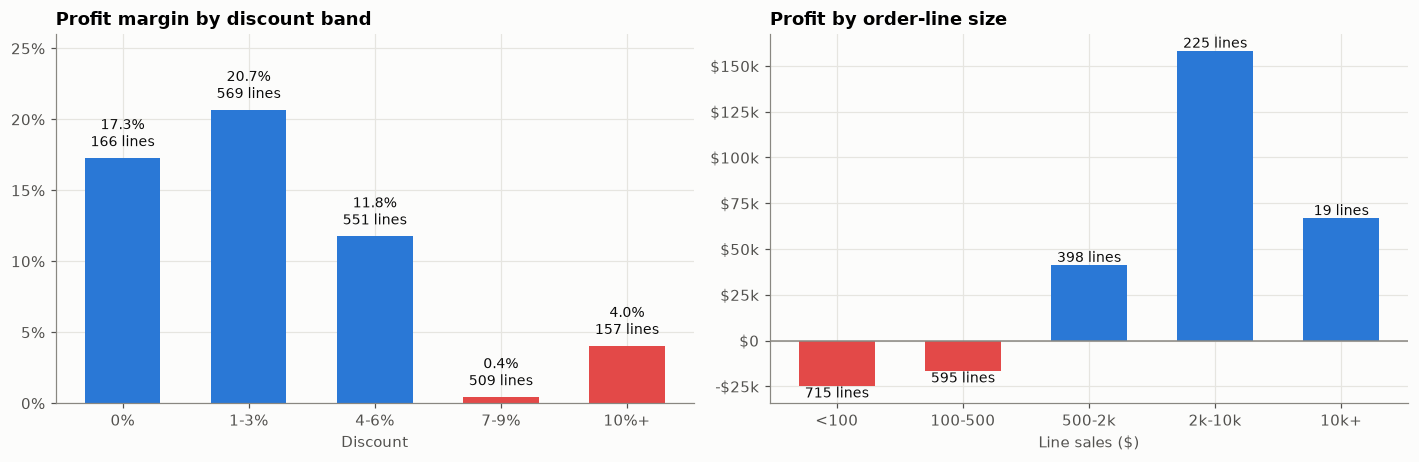

In [10]:
disc = summarize(df, "Discount Band").reindex(["0%", "1-3%", "4-6%", "7-9%", "10%+"])
size = summarize(df, "Order Size Band").reindex(["<100", "100-500", "500-2k", "2k-10k", "10k+"])
ship_ratio = df.groupby("Order Size Band")["Shipping Cost"].sum() / df.groupby("Order Size Band")["Sales"].sum()

fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 4.3))
a1.bar(disc.index, disc["margin"], color=np.where(disc["margin"] < 0.05, RED, BLUE), width=0.6)
for i, (mg, n) in enumerate(zip(disc["margin"], disc["lines"])):
    a1.text(i, mg + 0.005, f"{mg:.1%}\n{n} lines", ha="center", va="bottom", color=INK, fontsize=9)
a1.yaxis.set_major_formatter(pct); a1.set_ylim(0, 0.26)
a1.set_title("Profit margin by discount band"); a1.set_xlabel("Discount")

a2.bar(size.index, size["profit"], color=np.where(size["profit"] < 0, RED, BLUE), width=0.6)
a2.axhline(0, color=MUTED, lw=1)
for i, (p, n) in enumerate(zip(size["profit"], size["lines"])):
    a2.text(i, p, f"{n} lines", ha="center", va="bottom" if p > 0 else "top", color=INK, fontsize=9)
a2.yaxis.set_major_formatter(usd); a2.set_title("Profit by order-line size"); a2.set_xlabel("Line sales ($)")
fig.tight_layout(); save(fig, "05_discount_and_size")
size.assign(shipping_to_sales=ship_ratio)

These two charts contain the main findings.

* **Margin falls sharply above a 6% discount.** Lines at 1-3% discount earn a **20.7%** margin. At 7-9% the margin falls to **0.4%**, and at 10%+ it is 4%.
  About 666 lines (a third of the business) get 7%+ discounts and earn almost nothing.
* **Small lines lose money.** 1,310 lines under $500 (**67% of all lines**) lose **$42k** together. For lines under $100, shipping alone is **10% of sales** and the average margin is -76%.
  Lines over $2k are only 12% of volume but earn over 100% of net profit.

Recommendations: cap standard discounts at about 6% and require approval above that. Add a minimum order value or a small-order shipping fee.

## 7. Shipping & order priority

Ship Mode,Delivery Truck,Express Air,Regular Air
Order Priority,,,
Critical,1.38,1.60,1.38
High,1.40,1.41,1.33
Medium,1.46,1.34,1.42
Low,3.89,3.38,4.17
Not Specified,1.29,1.59,1.42


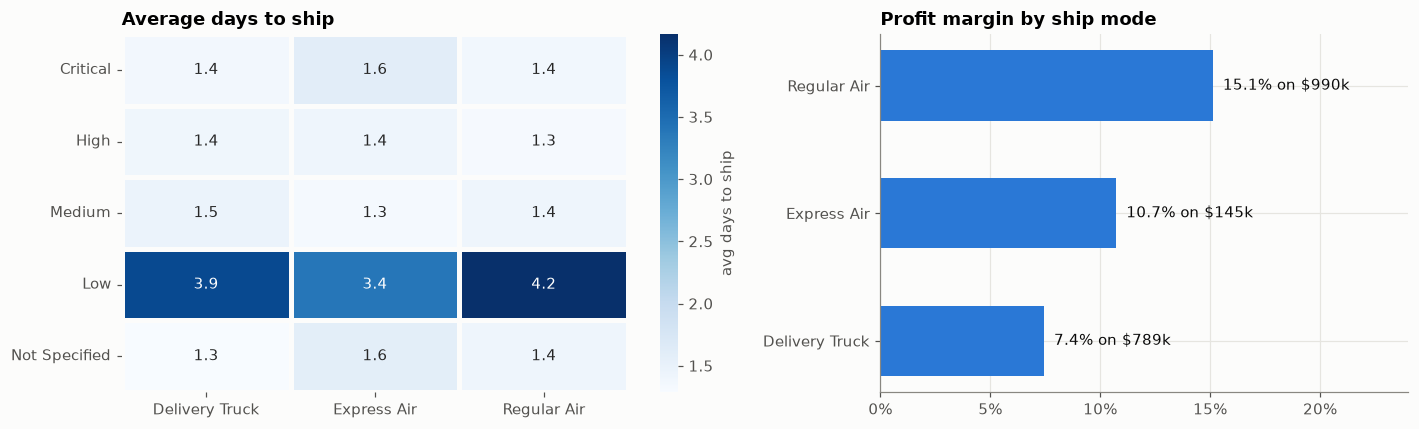

In [11]:
sd = df.pivot_table(index="Order Priority", columns="Ship Mode", values="Ship Days", aggfunc="mean").reindex(transform.PRIORITY_ORDER)
sm = summarize(df, "Ship Mode").sort_values("margin")

fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 4), width_ratios=[1.2, 1])
sns.heatmap(sd, annot=True, fmt=".1f", cmap="Blues", linewidths=2, linecolor="#fcfcfb",
            cbar_kws={"label": "avg days to ship"}, ax=a1)
a1.set_title("Average days to ship"); a1.set_xlabel(""); a1.set_ylabel(""); a1.tick_params(axis="y", rotation=0)
a2.barh(sm.index, sm["margin"], color=BLUE, height=0.55)
for i, (mg, s) in enumerate(zip(sm["margin"], sm["sales"])):
    a2.text(mg, i, f"  {mg:.1%} on ${s/1e3:,.0f}k", va="center", color=INK)
a2.xaxis.set_major_formatter(pct); a2.set_xlim(0, 0.24); a2.xaxis.set_major_locator(mtick.MultipleLocator(0.05)); a2.set_title("Profit margin by ship mode")
fig.tight_layout(); save(fig, "06_shipping")
sd

* **Order priority only matters for "Low".** Critical, High, Medium and Not Specified all ship in about 1.3-1.6 days. Low takes about 4 days.
  Paying for Express Air on a Critical order does not make it arrive sooner than Regular Air.
* **Delivery Truck carries 41% of sales at a 7.4% margin**, half the margin of Regular Air (15%). These are the large furniture items (Jumbo Box has a negative margin).
  Freight cost on bulky items should be priced into the quote.

## 8. Customers

,Customer Name,Customer Segment,Sales,cum_share,cust_share
0,Kristine Connolly,Corporate,"50,207.78",0.03,0.00
1,Nina Horne Kelly,Small Business,"48,295.12",0.05,0.00
2,Toni Swanson,Consumer,"32,194.12",0.07,0.00
3,Rosemary O'Brien,Consumer,"29,916.01",0.08,0.00
4,Yvonne Mann,Home Office,"28,779.13",0.10,0.00
5,Lee Xu,Consumer,"20,640.35",0.11,0.01
6,Erin Ballard,Home Office,"20,565.99",0.12,0.01
7,Tammy Raynor,Corporate,"18,642.71",0.13,0.01
8,Neal Wolfe,Consumer,"17,390.24",0.14,0.01
9,Andrew Levine,Small Business,"16,792.21",0.15,0.01


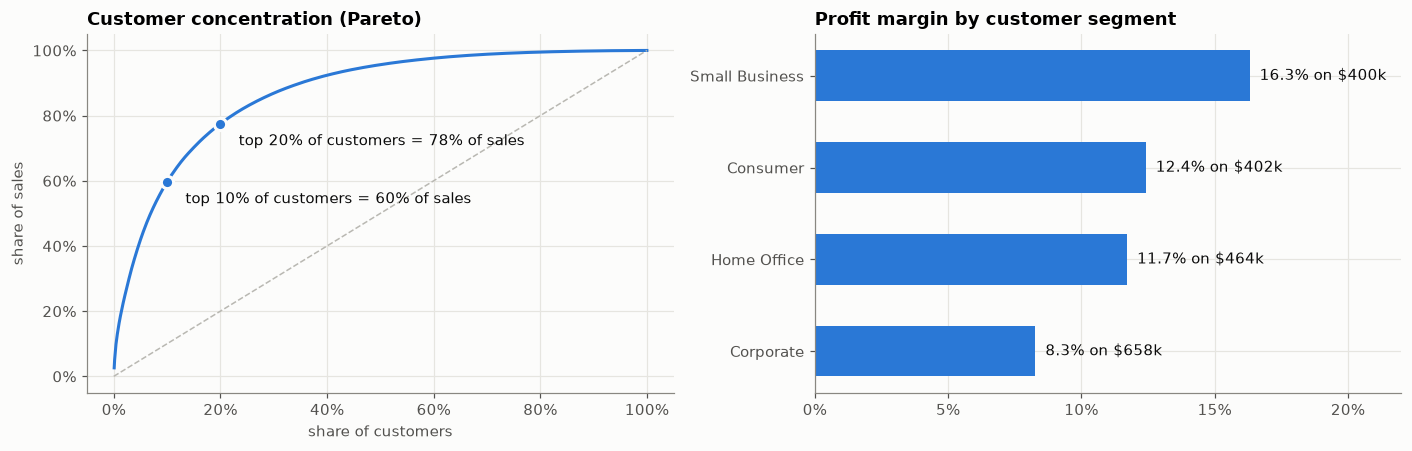

In [12]:
cust = df.groupby(["Customer Name", "Customer Segment"])["Sales"].sum().sort_values(ascending=False).reset_index()
cust["cum_share"] = cust["Sales"].cumsum() / cust["Sales"].sum()
cust["cust_share"] = np.arange(1, len(cust) + 1) / len(cust)
seg = summarize(df, "Customer Segment").sort_values("margin")

fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 4.2))
a1.plot(cust["cust_share"], cust["cum_share"], color=BLUE, lw=2)
a1.plot([0, 1], [0, 1], color=GRAY, lw=1, ls="--")
for q in (0.1, 0.2):
    y = cust.loc[cust["cust_share"] <= q, "cum_share"].iloc[-1]
    a1.plot(q, y, "o", color=BLUE, ms=8, mec="#fcfcfb", mew=2)
    a1.annotate(f"top {q:.0%} of customers = {y:.0%} of sales", (q, y), xytext=(12, -14),
                textcoords="offset points", color=INK)
a1.xaxis.set_major_formatter(pct); a1.yaxis.set_major_formatter(pct)
a1.set_title("Customer concentration (Pareto)"); a1.set_xlabel("share of customers"); a1.set_ylabel("share of sales")
a2.barh(seg.index, seg["margin"], color=BLUE, height=0.55)
for i, (mg, s) in enumerate(zip(seg["margin"], seg["sales"])):
    a2.text(mg, i, f"  {mg:.1%} on ${s/1e3:,.0f}k", va="center", color=INK)
a2.xaxis.set_major_formatter(pct); a2.set_xlim(0, 0.22); a2.xaxis.set_major_locator(mtick.MultipleLocator(0.05)); a2.set_title("Profit margin by customer segment")
fig.tight_layout(); save(fig, "07_customers")
cust.head(10)

* Sales are highly concentrated: **the top 10% of customers bring 60% of sales and the top 20% bring 78%.** Losing a few key accounts would hurt revenue a lot, so they deserve account management.
* **Corporate** is the largest segment ($658k) but has the **lowest margin (8.3%)**. Small Business has the best margin at 16%. Corporate customers likely negotiate larger discounts.

## 9. Returns

In [13]:
ret = df[df["Returned"]]
print(f"{ret['Order ID'].nunique()} returned orders / {df['Order ID'].nunique()} orders "
      f"({ret['Order ID'].nunique()/df['Order ID'].nunique():.1%}), {len(ret)} lines, ${ret['Sales'].sum():,.0f} sales")
ret.groupby(["Region", "Manager"])[["Sales", "Profit"]].agg(["sum", "count"])

11 returned orders / 1365 orders (0.8%), 15 lines, $43,650 sales


Sales         Profit      
                     sum count      sum count
Region Manager                               
East   Erin     6,712.46     7  -643.59     7
West   William 36,937.09     8 3,216.94     8

Only **11 of the 1,634 order IDs in `Returns` match an order here**. The Returns sheet appears to come from a larger (global) order book.
The matched returns are all in the West and East, and in total they are too few to support conclusions. The return flag is kept in the data, but I would not report a return rate from this data.

## 10. Data-quality caveats

In [14]:
checks = pd.Series({
    "Lines where Profit > Sales": int((df["Profit"] > df["Sales"]).sum()),
    "Lines where loss > 100% of Sales": int((df["Profit"] < -df["Sales"]).sum()),
    "Order IDs shared by >1 customer": int(df.loc[df["Order ID Shared"], "Order ID"].nunique()),
    "Duplicate Row ID values": int(df["Row ID"].duplicated().sum()),
    "Imputed base margins": int(df["Base Margin Imputed"].sum()),
    "Returns IDs with no matching order": int((~pd.read_excel(transform.RAW, sheet_name="Returns")["Order ID"].isin(df["Order ID"])).sum()),
    "Top-20 lines' share of total profit": f"{df['Profit'].nlargest(20).sum() / df['Profit'].sum():.0%}",
})
checks.to_frame("value")

,value
Lines where Profit > Sales,70
Lines where loss > 100% of Sales,369
Order IDs shared by >1 customer,104
Duplicate Row ID values,1
Imputed base margins,16
Returns IDs with no matching order,1623
Top-20 lines' share of total profit,54%


Treat line-level profit with caution. On 70 lines profit is **greater than the sale value**, and on others the loss is ten times the sale value. This is impossible for a real retail transaction.
Totals and group comparisons are still useful. **Any single outlier line should be checked against the source system before anyone acts on it.**
The top 20 lines produce 54% of total profit, so medians and loss-line shares (used above) are more reliable than sums alone.

## 11. Findings & recommendations

| # | Finding | Evidence | Recommendation |
|---|---|---|---|
| 1 | **Discounts above 6% remove the margin** | 1-3%: 20.7% margin; 7-9%: 0.4% | Cap standard discount at 6%; approval above that |
| 2 | **Small lines lose money** | 67% of lines are < $500 and lose $42k; shipping is 10% of sales under $100 | Minimum order value / small-order shipping fee; bundle consumables |
| 3 | **South is the only loss-making region** | -$14k; Technology -10% margin | Review Sam's Technology deals; NC and MT outliers first |
| 4 | **Profit improved sharply over H1** | Margin rose from ~0% (Jan/Mar) to 19-22% (May/Jun) | Find out what changed in Q2 and keep doing it |
| 5 | **Office Supplies is the most profitable category** | 16% margin vs 9-11% | Promote binders, paper, storage; cross-sell with Tech/Furniture |
| 6 | **Tables & Bookcases lose money** | Tables -$7k | Re-price or stop discounting; check freight on Jumbo Box items |
| 7 | **Order priority has no effect except Low** | Critical ships no faster than Not Specified | Charge for real express handling or simplify the priority levels |
| 8 | **Revenue is concentrated in few customers** | Top 10% of customers = 60% of sales | Key-account programme; keep an eye on Corporate discounting |
| 9 | **Returns data doesn't match** | 11 / 1,634 IDs match | Fix the Returns extract before reporting a return rate |